# 1.多层感知机
## 1.1 隐藏层
首先回想一下softmax模型框架，该模型通过单个仿射变换将输入直接映射到输出，然后进行softmax操作。如果我们的标签通过仿射变换后确实于输入数据相关，那么这种方法确实构用了。但是，**仿射变换中的线性是一个很强的假设。**
### 线性模型可能会不适用
线性意味着单调假设：任何特征的增大都会导致模型输出的增大（如果对应的权重为正）或者模型输出的减小（如果对应的权重为负）。而我们也可以很容易找出违反单调性的例子。</br>
1.体温高于37摄氏度的人来说，体温越高风险越高。而体温低于37度的人，体温越高则风险越低。</br>
2.对猫狗的图像进行分类。假设有一张猫的图片，原本猫的耳朵是深色，背景是浅色。对于线性模型来说，它可能学习到“深色像素越多，越像猫”的单调规律。但如果把图片反色（深色变浅，浅色变深），猫的耳朵变成了浅色，背景变成了深色，此时线性模型会因为所有像素强度都反向变化而完全混乱——它只会机械地根据每个像素的原始方向判断，导致错误地认为这张反色图是“狗”或其他东西。但实际上，人类依然能轻松识别这是猫，因为我们看到的是形状、轮廓、纹理等组合特征，而不是孤立的像素强度。这个例子生动地说明了线性模型的局限性：它无法理解“像素之间的关系”，只会死板地记住每个像素的独立贡献，因此当图像的整体色调反转时，它就彻底失效了。</br>

**深度神经网络的核心思想可以这样理解：原始数据（比如图像的像素）中，每个元素的意义都依赖于它与其他元素的复杂组合关系，我们无法靠人工规则来定义这种关系。但幸运的是，我们可以让模型自己从数据中学习——通过隐藏层自动构建出能捕捉特征交互的高级表示，然后再基于这种学到的表示进行线性分类。换句话说，深度神经网络不是直接处理原始数据，而是先自动学习如何将原始数据转换成更有意义的特征，再基于这些特征做决策，整个过程通过观察数据联合完成，无需人工干预。** </br>


**隐藏层能够自动构建高级表示，是因为神经网络通过多层非线性变换，像搭积木一样逐层组合简单特征。比如识别手写数字"8"：第一层隐藏层学习检测横线、竖线、斜线等基础边缘；第二层将这些边缘组合成弧线和圆圈；第三层将两个圆圈按上下位置组合起来；最终输出层判断这是"8"。整个过程就像自动化的"零件组装"——模型在训练中通过反向传播不断调整，让对分类有用的特征组合被强化，无用的被抑制，最终学会从原始像素中提炼出"两个上下堆叠的圆圈"这种高级概念。**

**非线性是神经网络的"灵魂"——它让网络能够学习"如果A且B，那么C"这种逻辑关系，能够设置阈值、做判断、组合特征。如果没有非线性，无论堆叠多少层，都只是把输入放大缩小再平移，永远无法理解"两个圆圈上下堆叠是8"这种复杂概念。**

### 在网络中加入隐藏层
**我们可以通过在网络中加入一个或多个隐藏层来突破线性模型的限制，使其能处理更加普遍的函数关系类型。** 要做到这一点，最简单的方法是**将许多全连接层堆叠在一起。** 每一层的输出到其上面的层，知道生成最后的输出。我们可以把前$L-1$层看作表示，把最后一层看作线性预测器。这种架构通常称为**多层感知机（multilayer perceptron, MLP）**。
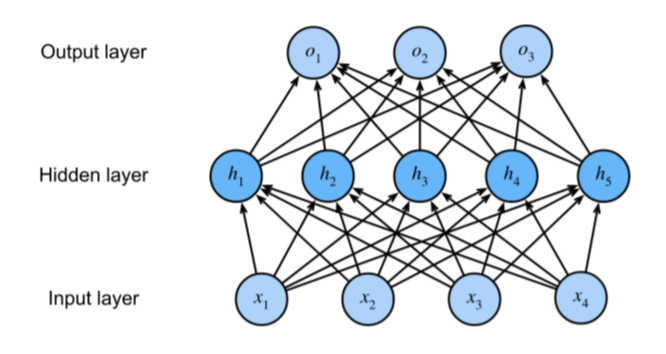

### 从线性到非线性
我们通过矩阵$X \in R^{n \times d}$来表示有n个样本的小批量，其中每个样本具有d个输入特征。$H \in R^{n \times h}$表述具有h个隐藏单元的单隐藏层多层感知机，称为**隐藏表示。** 因为隐藏层和输出层都是全连接的，所以我们有隐藏层权重$W^{(1)} \in R^{d \times h}$和隐藏层偏执$b ^{(1)} \in R^{1 \times h}$ 以及输出层权重$W^{(2)} \in R^{h \times q}$和输出层偏执$b ^{(2)} \in R^{1 \times q}$。形式上，我们按如下方式计算单隐藏层多层感知机的输出$O \in R^{n \times q}$:
$$
H = XW^{(1)} + b^{(1)} \ \ \ O = HW^{(2)} + b^{(2)}
$$

在上面定义的模型里，没有任何好处。原因很简单：上面的隐藏单元由输入的仿射函数给出，输出只是隐藏单元的仿射函数。仿射函数本身还是还是放射函数（依旧是线性的），如果这样的话我们之前的线性模型已经能够表示任何仿射函数。这只是做的无用功。</br>
我们可以证明这一等价性，即对于任意权重值，我们只需要合并隐藏层，便可以产生具有$W = W^{(1)}W^{(2)}、b=b^{(1)}W^{(2)} + b^{(2)}$的等价单层模型：
$$
O = (XW^{(1)}+ b^{(1)})W^{(2)} + b^{(2)} = XW^{(1)}W^{(2)} + b^{(1)}W^{(2)} + b^{(2)} = XW + b
$$

为了发挥多层架构的潜力，我们还需要一个额外的关键要素：在仿射变换之后对每个隐藏单元应用非线性的**激活函数**$\sigma$。激活函数的输出称为激活值。一般来说，**有了激活函数，就不可能再将我们的多层感知机退化成线性模型：**
$$
H = \sigma(XW^{(1)} + b^{(1)}) \  \ \ \ O = HW^{(2)} + b^{(2)}
$$
**隐藏层是加了激活函数的全连接层。** </br>
激活函数的核心作用是为模型引入非线性，使其能够拟合和表达现实世界中复杂的非线性关系。如果只使用线性函数，无论网络有多少层，最终都等价于一次线性变换，模型只能学习“直线”关系，无法处理图像识别、语音理解等复杂任务。

为了构建更通用的多层感知机，我们可以继续堆叠这样的隐藏层，例如$H^{(1)} = \sigma_1(XW^{(1)} + b^{(1)})、H^{(2)} = \sigma_2(H^{(1)}W^{(2)} + b^{(2)})$，一层叠一层，从而生成更有表达力的模型。

### 通用近似定理
多层感知机可以通过隐藏层中的神经元捕获输入之间复杂的相互作用，这些神经元依赖每个输入的值。我们可以很容易地设计隐藏节点来执行任意计算。

## 1.2 激活函数
激活函数通过计算加权和并加上偏执来确定神经元是否应该将输入信号转换为输出的可微运算。大多数激活函数都是非线性的。接下来介绍一些常见的激活函数。

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

### ReLU函数
最受欢迎的激活函数是**修正线性单元（rectified linear unit, ReLU）**，因为它实现起来简单，同时在各种预测任务中表现良好。**ReLU**提供了一种非常简单的非线性变换。给定元素x，ReLU函数被定义为该元素于与0中的最大值：
$$
ReLU(x) = max(x, 0)
$$
说人话，ReLU通过将相应的激活值设为0，仅仅保留正元素并丢弃所有负元素。如下所示：

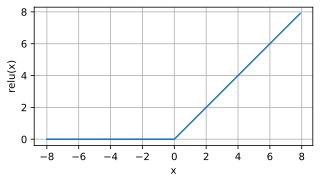

In [2]:
x =torch.arange(-8.0, 8.0, 0.1, requires_grad = True)
y = torch.relu(x)
d2l.plot(x.detach(), y.detach(), 'x', 'relu(x)', figsize = (5, 2.5)) # detach() 的作用是从计算图中分离出张量，使其不再需要梯度。

当输入为负时，ReLU函数的导数为0，当输入为正时，ReLU的导数为1。当输入为0时，ReLU函数不可导。此时我们默认使用左侧的导数，即当输入为0时，导数也为0。

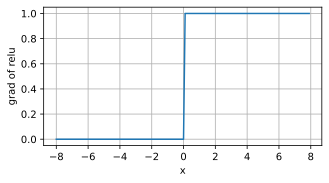

In [3]:
y.backward(torch.ones_like(x), retain_graph = True)
"""
    # torch.ones_like(x) 的作用：
        gradient = torch.ones_like(x)  # 创建一个和x形状相同的全1张量
        # 这表示我们对y的每个分量都同样重视
        # 相当于计算每个y_i对x_i的导数

        标量输出：直接 backward()
        向量输出：需要传入一个和输出形状相同的权重张量
    
    retain_graph=True 的作用:
        # 默认情况下，计算完梯度后会释放计算图
        # retain_graph=True 表示保留计算图，以便后续可能再次使用
        # 这里虽然只计算一次梯度，但写上是个好习惯

    # 执行 y.backward() 后，PyTorch自动计算了dy/dx
    # 并将结果存储在 x.grad 中
"""

d2l.plot(x.detach(), x.grad, 'x', 'grad of relu', figsize=(5, 2.5))

使用ReLU的原因是，它的求导表现特别好：**要么让参数消失，要么让参数通过。这使得优化变现更好，并且ReLU缓解了以往神经网络梯度消失的问题。**

### sigmoid函数
对于定义域在R上的输入，sigmoid函数将输入变换为区间（0，1）上的输出，通常被称为**挤压函数**：它将范围(-inf,inf)上的任意输入压缩到区间(0,1)上的某个值：
$$
sigmoid(x) = \frac{1}{1 + exp(x)}
$$
在最早的神经网络中，人们大多都关心是对神经元的“激活”或“不激活”感兴趣。所以一些先行者专注于阈值单元。阈值的那元在输入低于某个阈值时取值0，高于某个阈值时取值1。</br>
当人们逐渐关注基于梯度的学习时，sigmoid函数是一个自然的选择，因为它是一个平滑的、可微的阈值单元的近似函数。sigmoid还可以被是做为softmax的特例，然而，大部分的时候sigmoid被更简单、更容易训练的ReLU所取代。

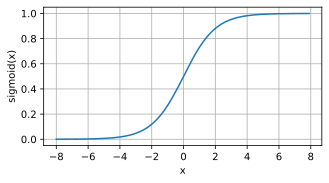

In [5]:
y = torch.sigmoid(x)
d2l.plot(x.detach(), y.detach(), 'x', 'sigmoid(x)', figsize = (5, 2.5))

sigmoid函数的导数是：
$$
\frac{d}{dx}sigmoid(x) = \frac{exp(-x)}{(1 + exp(-x))^2} = sigmoid(x)(1 - sigmoid(x))
$$

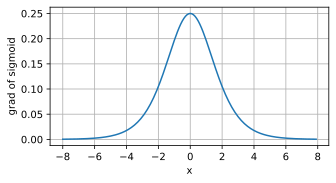

In [9]:
# sigmoid 导数图像
# 清除以前的梯度
x.grad.data.zero_()
y.backward(torch.ones_like(x), retain_graph = True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of sigmoid', figsize = (5, 2.5))

### tanh函数
与sigmoid函数类似，tanh函数也能将器输入压缩转换到区间(-1, 1)上。tanh函数如下：
$$
tanh(x) = \frac{1-exp(-2x)}{1+exp(-2x)}
$$
tanh函数图像，当输入接近0时，tanh函数接近线性变换。函数的形状类似于sigmoid函数，不同的是tanh函数关于坐标原点中心对称。

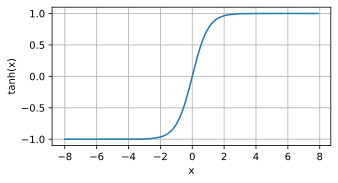

In [10]:
y = torch.tanh(x)
d2l.plot(x.detach(), y.detach(), 'x', 'tanh(x)', figsize=(5, 2.5))

tanh函数的导数是：
$$
\frac{d}{dx}tanh(x) = 1 - tanh^2(x)
$$
导数图像如下：

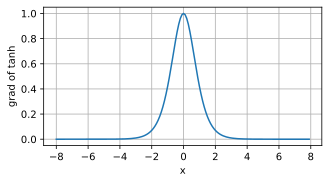

In [12]:
x.grad.data.zero_()
y.backward(torch.ones_like(x), retain_graph = True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of tanh', figsize = (5, 2.5))